In [15]:
#class imbalance >> when one class has higher percentage
#handle:
#upsampling
#downsampling 
#SMOTE

In [16]:
import pandas as pd
import numpy as np

np.random.seed(1) #for reproducibility of result

no_samples = 1000
class_0_ratio = 0.9
no_class_0 = int(no_samples*class_0_ratio)
no_class_1 = 100

In [17]:
no_class_0, no_class_1

(900, 100)

In [18]:
class_0 = {'feature1': np.random.normal(0, 1, no_class_0),
          'feature2': np.random.normal(0, 1, no_class_0),
          'target': [0]*no_class_0}

In [19]:
class_0 = pd.DataFrame(class_0)

In [20]:
class_0


,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [21]:
class_1 = pd.DataFrame({'feature1': np.random.normal(3, 1, no_class_1),
          'feature2': np.random.normal(3, 1, no_class_1),
          'target': [1]*no_class_1})

In [22]:
df = pd.concat([class_0, class_1]).reset_index(drop=True)

In [23]:
df

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [25]:
df.target.value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [31]:
#upsampling
df_minority= df[df.target == 1]
df_majority  = df[df.target == 0]

In [33]:
df_majority

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [36]:
!pip install sklearn

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates from a subpr

In [38]:
#replace >> if replace is true, it means data point can be repeated
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace = True, n_samples= len(df_majority), random_state = 1)

In [39]:
df_minority_upsampled.shape

(900, 3)

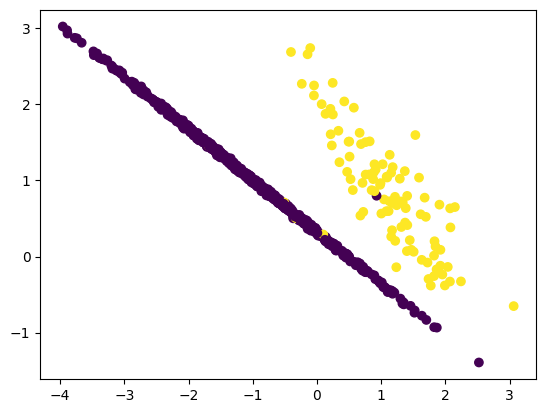

In [69]:
plt.scatter(smote_df['f1'], smote_df['f2'], c = smote_df['target'])

In [70]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [71]:
df_upsampled.target.value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [72]:
#downsampling
df_minority

,feature1,feature2,target
900,1.692029,3.933630,1
901,4.472396,1.236225,1
902,3.074876,2.589783,1
903,1.213065,2.546333,1
904,3.165211,2.410570,1
...,...,...,...
995,3.213026,3.188583,1
996,2.195458,3.560918,1
997,2.353418,2.078341,1
998,4.138173,3.647375,1


In [43]:
df_majority

,feature1,feature2,target
0,1.624345,-0.446699,0
1,-0.611756,0.204377,0
2,-0.528172,0.612233,0
3,-1.072969,0.744885,0
4,0.865408,-0.036281,0
...,...,...,...
895,0.578464,0.833679,0
896,-0.961264,2.160456,0
897,-1.458324,1.998992,0
898,0.494342,0.764041,0


In [44]:
df_majority_downsampled = resample(df_majority, replace = False, n_samples = len(df_minority), random_state=1)

In [45]:
df_majority_downsampled

,feature1,feature2,target
860,-0.977773,0.872579,0
880,0.309817,1.835870,0
874,0.050317,0.146532,0
780,0.677808,-0.859827,0
525,0.713049,0.320971,0
...,...,...,...
494,-1.579156,2.711950,0
255,-1.044589,0.522655,0
672,0.410266,0.683356,0
481,-1.114871,-0.800787,0


In [46]:
df_downsampled = pd.concat([df_minority, df_majority_downsampled])

In [47]:
df_downsampled.target.value_counts()

target
1    100
0    100
Name: count, dtype: int64

In [48]:
#SMOTE>> SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE

In [51]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_redundant=0, n_features = 2, n_clusters_per_class=1, weights = [0.90])

In [52]:
X

array([[-1.51821333,  1.35955121],
       [-2.83019665,  2.19889382],
       [-0.43957562,  0.64372618],
       ...,
       [-0.36862429,  0.58175248],
       [ 0.20596046,  0.18361219],
       [-0.82413762,  0.87644587]])

In [54]:
y

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,

In [55]:
df1 = pd.DataFrame(X, columns = ['f1', 'f2'])
df2 = pd.DataFrame(y, columns = ['target'])
final_df = pd.concat([df1, df2], axis = 1)

In [56]:
final_df

,f1,f2,target
0,-1.518213,1.359551,0
1,-2.830197,2.198894,0
2,-0.439576,0.643726,0
3,-1.898158,1.603483,0
4,0.311843,0.126998,0
...,...,...,...
995,-1.379980,1.266650,0
996,0.124204,0.220194,0
997,-0.368624,0.581752,0
998,0.205960,0.183612,0


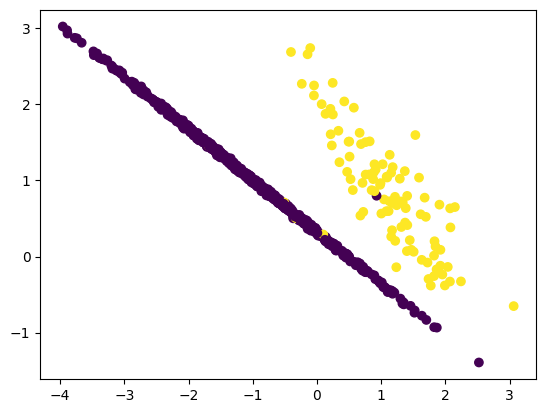

In [75]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c = final_df['target'])

In [58]:
final_df

,f1,f2,target
0,-1.518213,1.359551,0
1,-2.830197,2.198894,0
2,-0.439576,0.643726,0
3,-1.898158,1.603483,0
4,0.311843,0.126998,0
...,...,...,...
995,-1.379980,1.266650,0
996,0.124204,0.220194,0
997,-0.368624,0.581752,0
998,0.205960,0.183612,0


In [63]:
!pip  install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
   ---------------------------------------- 0.0/238.4 kB ? eta -:--:--
   ------------ --------------------------- 71.7/238.4 kB 2.0 MB/s eta 0:00:01
   ----------------------------- ---------- 174.1/238.4 kB 2.6 MB/s eta 0:00:01
   ----------------------------- ---------- 174.1/238.4 kB 2.6 MB/s eta 0:00:01
   ----------------------------- ---------- 174.1/238.4 kB 2.6 MB/s eta 0:00:01
   ----------------------------- ---------- 174.1/238.4 kB 2.6 MB/s eta 0:00:01
   ----------------------------- -------- 184.3/238.4 kB 740.8 kB/s eta 0:00:01
   ----------------------------------- -- 225.3/238.4 kB 724.0 kB/s eta 0:00:01
   -------------------------------------  235.5/238.4 kB 625.8 kB/s eta 0:00:01
   -------------------------------------- 238.4/238.4 kB 633.7 kB/s eta 0:00:00


In [64]:
#!pip  install imblearn
from imblearn.over_sampling import SMOTE
oversample  = SMOTE()

In [ ]:
X, y = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [65]:
X.shape

(1000, 2)

In [66]:
df1 = pd.DataFrame(X, columns = ['f1', 'f2'])
df2 = pd.DataFrame(y, columns = ['target'])
smote_df = pd.concat([df1, df2], axis = 1)

In [67]:
smote_df

,f1,f2,target
0,-1.518213,1.359551,0
1,-2.830197,2.198894,0
2,-0.439576,0.643726,0
3,-1.898158,1.603483,0
4,0.311843,0.126998,0
...,...,...,...
995,-1.379980,1.266650,0
996,0.124204,0.220194,0
997,-0.368624,0.581752,0
998,0.205960,0.183612,0


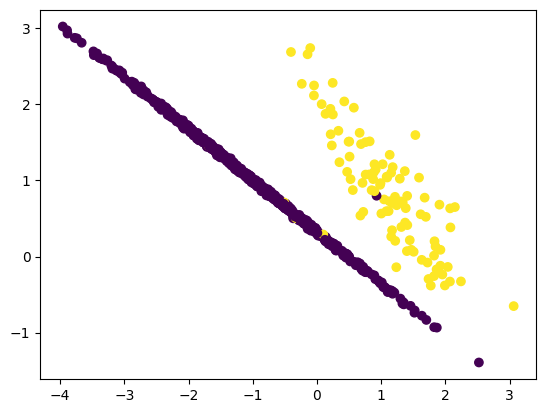

In [68]:
plt.scatter(smote_df['f1'], smote_df['f2'], c = smote_df['target'])

In [76]:
# inthe SMOTE it create the new minority data that near the minority data for the increase the minority data  

In [ ]:
# here having some diff matplolib data showing but actully is first graph its look just little bit away
and the lesser in theis last o/p it shows thw large dada and the increased the minority data near the minority